## 🔧 Fine-Tuning EnergyTTM

This notebook performs **fine-tuning of the pretrained EnergyTTM model** on downstream energy forecasting data to adapt it to specific buildings or datasets.

The workflow includes:
- Loading pretrained EnergyTTM weights
- Preparing and cleaning time-series energy data
- Training the model using supervised forecasting objectives
- Evaluating performance using standard forecasting metrics

The objective is to improve task-specific performance by adapting EnergyTTM to the target dataset while leveraging pretrained representations.

In [ ]:
import os
import random 
from time import time
import math 
import torch 
import warnings
import json
import torch.nn as nn

import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np 
import pandas as pd
from transformers import Trainer, TrainingArguments, set_seed, EarlyStoppingCallback
from torch.utils.data import Dataset, DataLoader
from tsfm_public.models.tinytimemixer.configuration_tinytimemixer import TinyTimeMixerConfig
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction
from tsfm_public.toolkit.util import select_by_index

warnings.filterwarnings("ignore")
SEED = 42
set_seed(SEED)


### Load the Dataset

The dataset is provided in **Parquet format** for efficient storage and fast I/O.  
You can load it using `pandas` as shown below.

If you wish to use your own dataset (CSV, Parquet, etc.), simply replace the file path and loading method accordingly.  
We assume the loaded dataframe contains at least one column representing the **time series values** (e.g., electricity consumption), which will be used for downstream forecasting or analysis.

In [3]:
df = pd.read_parquet('../Dataset/Forecasting/Mathura-1H.parquet')

In [4]:
df.head()

,MH01,MH02,MH03,MH06,MH07,MH08,MH09,MH10,MH11,MH12,...,MH36,MH37,MH38,MH39,MH41,MH42,MH43,MH45,MH46,MH47
Timestamp,,,,,,,,,,,,,,,,,,,,,
2019-05-01 00:00:00,0.262,2.039,NaN,0.437,1.915,0.302,0.283,2.484,0.788,0.342,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-05-01 01:00:00,0.309,2.036,NaN,0.406,1.878,0.321,0.235,2.438,0.799,0.360,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-05-01 02:00:00,0.315,2.018,NaN,0.404,1.822,0.321,0.243,2.332,0.815,0.371,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-05-01 03:00:00,0.318,2.018,NaN,0.470,1.844,0.333,0.272,2.322,0.822,0.314,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-05-01 04:00:00,0.324,2.045,NaN,0.479,1.786,0.322,0.333,2.313,0.592,0.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Let us pick one building from this dataset for our study

In [92]:
target_col = "MH36"
build_df = df[[target_col]]
build_df.head()

,MH36
Timestamp,
2019-05-01 00:00:00,NaN
2019-05-01 01:00:00,NaN
2019-05-01 02:00:00,NaN
2019-05-01 03:00:00,NaN
2019-05-01 04:00:00,NaN


### EDA for the building

In [93]:
build_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15888 entries, 2019-05-01 00:00:00 to 2021-02-20 23:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MH36    11491 non-null  float64
dtypes: float64(1)
memory usage: 764.3+ KB


In [94]:
build_df.isna().sum()

MH36    4397
dtype: int64

INFO:p-1490054:t-126060884662080:category.py:update:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:p-1490054:t-126060884662080:category.py:update:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


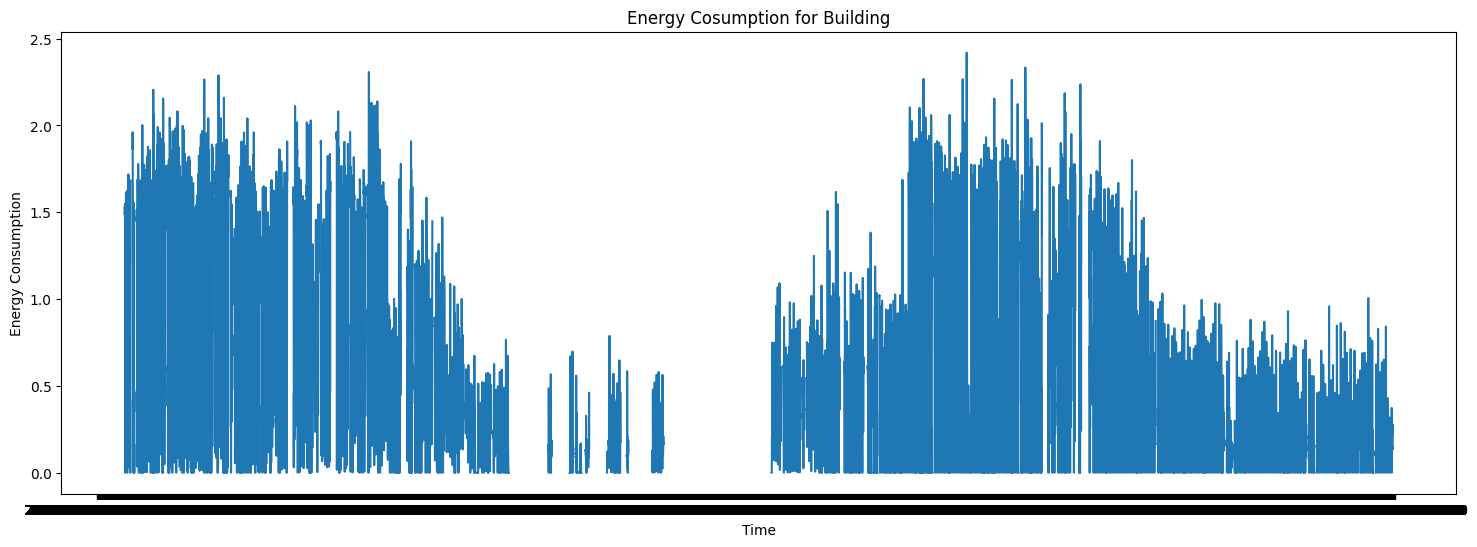

In [95]:
# Plot
# plt.figure()

plt.figure(figsize=(18, 6))
plt.plot(df.index, build_df[target_col])
plt.xlabel("Time")
plt.ylabel("Energy Consumption")
plt.title("Energy Cosumption for Building")
plt.show()

In [96]:
def clean_series(energy_data):
    """
    Replace NaN values in a time series with the median of the series.

    Parameters:
        energy_data (np.array): Raw energy time series.

    Returns:
        np.array: Cleaned energy time series.
    """
    nan_count = np.isnan(energy_data).sum()
    
    if nan_count > 0:
        # Compute median ignoring NaNs
        median_val = np.nanmedian(energy_data)
        
        # Replace NaNs with median value
        energy_data = np.where(np.isnan(energy_data), median_val, energy_data)
        
        print(f"  Filled {nan_count} NaNs with median={median_val:.4f}")
    
    return energy_data

In [97]:
build_df[f"{target_col}_cleaned"] = clean_series(build_df[target_col])


  Filled 4397 NaNs with median=0.3690


INFO:p-1490054:t-126060884662080:category.py:update:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:p-1490054:t-126060884662080:category.py:update:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


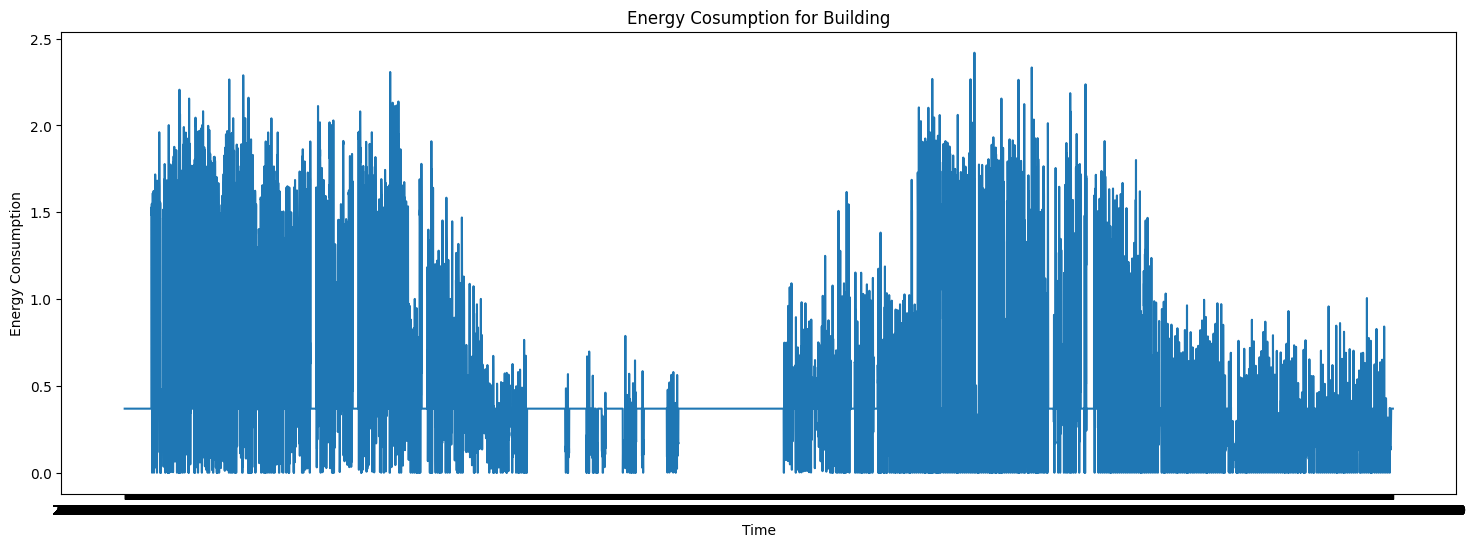

In [98]:
plt.figure(figsize=(18, 6))
plt.plot(build_df.index, build_df[f"{target_col}_cleaned"])
plt.xlabel("Time")
plt.ylabel("Energy Consumption")
plt.title("Energy Cosumption for Building")
plt.show()

EnergyFM Expects data in a certain format

In [99]:


def standardize_series(series, eps=1e-8):
    mean = np.mean(series)
    std = np.std(series)
    standardized_series = (series - mean) / (std+eps)
    return standardized_series, mean, std

def unscale_predictions(predictions, mean, std, eps=1e-8):
    return predictions * (std+eps) + mean


class TimeSeriesDataset(Dataset):
    def __init__(self, data, backcast_length, forecast_length, stride=1):
        # Standardize the time series data
        self.data, self.mean, self.std = standardize_series(data)
        self.backcast_length = backcast_length
        self.forecast_length = forecast_length
        self.stride = stride

    def __len__(self):
        return (len(self.data) - self.backcast_length - self.forecast_length) // self.stride + 1

    def __getitem__(self, index):
        start_index = index * self.stride
        x = self.data[start_index : start_index + self.backcast_length]
        y = self.data[start_index + self.backcast_length : start_index + self.backcast_length + self.forecast_length]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


In [100]:
def clean_and_validate_series(energy_data, args):
    """
    Clean a single energy time series and validate whether it can form a dataset.

    Steps:
    - Check if the series is long enough
    - Create a TimeSeriesDataset
    - Ensure dataset contains at least one sample

    Returns:
        TimeSeriesDataset if valid, otherwise None
    """

    # Minimum length required to form at least one sliding window
    min_required = args["context_length"] + args["prediction_length"]

    # Skip series if too short
    if len(energy_data) < min_required:
        return None

    # Create sliding window dataset
    dataset = TimeSeriesDataset(
        energy_data,
        args["context_length"],
        args["prediction_length"],
        args["patch_stride"],
    )

    # Ensure dataset contains samples
    if len(dataset) == 0:
        return None

    return dataset



In [101]:
def create_dataset_if_valid(energy_data, args):
    """
    Create a TimeSeriesDataset if the series length is sufficient.

    Parameters:
        energy_data (np.array): Cleaned energy time series.
        args (dict): Configuration containing:
                     - context_length
                     - prediction_length
                     - patch_stride

    Returns:
        TimeSeriesDataset or None: Dataset object if valid, otherwise None.
    """
    # Minimum required length to form at least one training sample
    min_required = args["context_length"] + args["prediction_length"]

    # Skip if series is too short
    if len(energy_data) < min_required:
        print("   Too short, skipping...")
        return None

    # Create dataset using sliding windows
    dataset = TimeSeriesDataset(
        energy_data,
        args["context_length"],
        args["prediction_length"],
        args["patch_stride"]
    )

    # Ensure dataset contains at least one sample
    if len(dataset) == 0:
        print("   No samples, skipping...")
        return None

    return dataset



In [102]:
build_df.head()

,MH36,MH36_cleaned
Timestamp,,
2019-05-01 00:00:00,NaN,0.369
2019-05-01 01:00:00,NaN,0.369
2019-05-01 02:00:00,NaN,0.369
2019-05-01 03:00:00,NaN,0.369
2019-05-01 04:00:00,NaN,0.369


### Split the dataset into finetune and test set


Lets use first 8 months of data for finetuning, and next 6 months of data for testing

In [103]:
split_idx = int(len(build_df) * 0.75)

train_df = build_df[f"{target_col}_cleaned"].iloc[:split_idx]
test_df  = build_df[f"{target_col}_cleaned"].iloc[split_idx:]


In [104]:
config_file = '../Energy-TTM/config/tinyTimeMixers.json'

with open(config_file, 'r') as f:
    args = json.load(f)



In [105]:
train_dataset = create_dataset_if_valid(train_df,args=args)
test_dataset = create_dataset_if_valid(test_df,args=args)

In [106]:
train_dataset[0]

(tensor([-0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635,
         -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635,
         -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635,
         -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635,
         -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635,
         -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635,
         -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635,
         -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635,
         -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635,
         -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635,
         -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635,
         -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635, -0.4635,
         -0.4635, -0.4635, -

## Loading The model

In [128]:
model = TinyTimeMixerForPrediction.from_pretrained(
    "sriv-naman-iisc/Energy-FM-v1",  # Name of the model on Hugging Face
    revision="energy-ttm",
    num_input_channels=1,  # tsp.num_input_channels 
).to('cuda')

In [127]:
from tsfm_public.models.tspulse.modeling_tspulse import TSPulseForReconstruction, get_fft

In [129]:
model = TSPulseForReconstruction.from_pretrained(
    "sriv-naman-iisc/Energy-FM-v1",
    revision="energy-tspulse"
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/688k [00:00<?, ?B/s]

In [123]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader   = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [124]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=3e-4)


In [125]:
num_epochs = 20
criterion = torch.nn.MSELoss()

for epoch in range(num_epochs):

    model.train()   # Enable training mode
    train_losses = []

    for x_train, y_train in train_loader:

        # Add channel dimension if needed
        x_train = x_train.unsqueeze(-1).to(device)
        y_train = y_train.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        # print(x_train)
        output = model(x_train)
        # print(output)
        # break
        forecast = output.prediction_outputs.squeeze(-1)

        # Compute loss
        loss = criterion(forecast, y_train)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        train_losses.append(loss.item())

    avg_train_loss = sum(train_losses) / len(train_losses)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.6f}")


Epoch [1/20] Train Loss: 0.542435
Epoch [2/20] Train Loss: 0.554633
Epoch [3/20] Train Loss: 0.523220
Epoch [4/20] Train Loss: 0.506554
Epoch [5/20] Train Loss: 0.520415
Epoch [6/20] Train Loss: 0.505479
Epoch [7/20] Train Loss: 0.505175
Epoch [8/20] Train Loss: 0.492620
Epoch [9/20] Train Loss: 0.503840
Epoch [10/20] Train Loss: 0.505193
Epoch [11/20] Train Loss: 0.514278
Epoch [12/20] Train Loss: 0.504420
Epoch [13/20] Train Loss: 0.484234
Epoch [14/20] Train Loss: 0.499360
Epoch [15/20] Train Loss: 0.502220
Epoch [16/20] Train Loss: 0.485467
Epoch [17/20] Train Loss: 0.485035
Epoch [18/20] Train Loss: 0.470853
Epoch [19/20] Train Loss: 0.483510
Epoch [20/20] Train Loss: 0.492666


In [112]:
model.eval()

all_preds = []
all_truth = []

with torch.no_grad():
    for x_test, y_test in test_loader:

        x_test = x_test.unsqueeze(-1).to(device)
        y_test = y_test.to(device)

        output = model(x_test)
        forecast = output.prediction_outputs.squeeze(-1)

        all_preds.append(forecast.cpu().numpy())
        all_truth.append(y_test.cpu().numpy())


In [113]:
import numpy as np

y_pred = np.concatenate(all_preds, axis=0).reshape(-1)
y_true = np.concatenate(all_truth, axis=0).reshape(-1)


In [114]:
y_pred

array([ 1.1890823 ,  1.5643232 ,  1.1626265 , ..., -0.43049714,
       -0.2825725 , -0.23223588], shape=(3792,), dtype=float32)

In [115]:
all_preds = np.concatenate(all_preds, axis=0)

T_test = len(test_df)

forecast_sum = np.zeros(T_test)
forecast_count = np.zeros(T_test)

num_windows = all_preds.shape[0]

for start in range(num_windows):

    pred_window = all_preds[start]  # shape = (prediction_length,)

    forecast_start = start + args["context_length"]
    forecast_end   = forecast_start + args["prediction_length"]

    forecast_sum[forecast_start:forecast_end] += pred_window
    forecast_count[forecast_start:forecast_end] += 1

# Average overlaps
final_test_forecast = np.full(T_test, np.nan)

mask = forecast_count > 0
final_test_forecast[mask] = forecast_sum[mask] / forecast_count[mask]


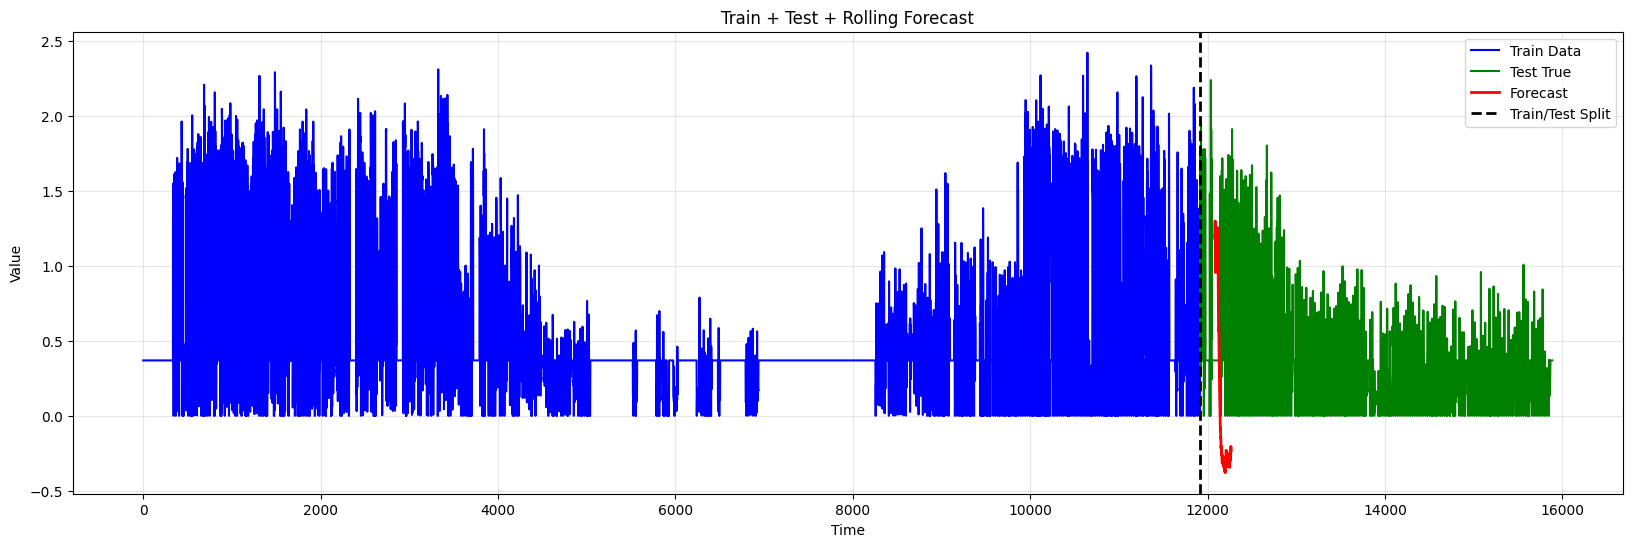

In [116]:
import numpy as np
train_series = train_df.values
test_series  = test_df.values

full_series = np.concatenate([train_series, test_series])

full_forecast = np.full_like(full_series, np.nan)

test_start_idx = len(train_series)

# Insert test forecast in correct global location
full_forecast[test_start_idx:] = final_test_forecast


import matplotlib.pyplot as plt

plt.figure(figsize=(20,6))

# Train data
plt.plot(
    range(len(train_series)),
    train_series,
    label="Train Data",
    color="blue"
)

# Test true data
plt.plot(
    range(len(train_series), len(full_series)),
    test_series,
    label="Test True",
    color="green"
)

# Forecast (only appears in test region after context window)
plt.plot(
    range(len(full_series)),
    full_forecast,
    label="Forecast",
    color="red",
    linewidth=2
)

# Train/Test split line
plt.axvline(
    len(train_series),
    color="black",
    linestyle="--",
    linewidth=2,
    label="Train/Test Split"
)

plt.title("Train + Test + Rolling Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
